# LSTM Model for CA20B (Window Size: 24 hours)

## Set Up

Import the necessary libraries:

In [16]:
import sys

# Print python version
print("Python version:", sys.version)

# Get a list of modules that you have imported
imported_modules = [
    'pandas', 'numpy', 'matplotlib', 'seaborn', 'xgboost', 
    'six', 'sklearn', 'tensorflow', 'graphviz', 'keras'
]

# Print the name and version of each imported module
for module in imported_modules:
    try:
        imported_module = __import__(module)
        version = imported_module.__version__
        print(f"{module} version: {version}")
    except AttributeError:
        # Some modules may not have versions
        print(f"{module} version not found")


Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas version: 2.2.3
numpy version: 2.1.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
xgboost version: 3.0.0
six version: 1.17.0
sklearn version: 1.6.1
tensorflow version: 2.19.0
graphviz version: 0.20.3
keras version: 3.9.0


In [1]:
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import os
import datetime
import pickle

# Set random seeds for reproducibility
seed_value = 42  # You can change this value to any integer
np.random.seed(seed_value)
random.seed(seed_value)
tf.random.set_seed(seed_value)

# Get current time
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

## Data Split

Load and preprocess the data:

In [2]:
# Define the station and window size
station = "CA20B"
window_size = 24 # Use past window_size hours as input

filename = f"{station}-{window_size}-hour"

# Create a folder to save models and results
folder_path = "../models/lstm/"+station+"/window-"+str(window_size)+"-hour/"+current_time
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Load the station data
url = "../data/raw/"+station+".csv"
data = pd.read_csv(url, index_col='DATE TIME', parse_dates=['DATE TIME'])

# Identify features and target
all_features = data.columns.to_list()
features = all_features[:-1]
target = all_features[-1]

In [3]:
# Split the data into training and test sets
train_size = int(0.8 * len(data))
train_data = data[:train_size]
test_data = data[train_size:]

# Normalize the training data
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Normalize the test data using the same scaler (no fitting here, just transforming)
test_data_scaled = scaler.transform(test_data)

X_train, y_train = [], []
for i in range(len(train_data_scaled) - window_size):
    X_train.append(train_data_scaled[i:i+window_size, :])  # Past window_size hours (features)
    y_train.append(train_data_scaled[i+window_size, -1])   # Next day's API value

X_train = np.array(X_train)  # Shape: (num_samples, 30, num_features)
y_train = np.array(y_train)  # Shape: (num_samples,)


X_test, y_test = [], []
for i in range(len(test_data_scaled) - window_size):
    X_test.append(test_data_scaled[i:i+window_size, :])
    y_test.append(test_data_scaled[i+window_size, -1])

X_test = np.array(X_test)
y_test = np.array(y_test)

Define the LSTM model architecture:

In [4]:
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])


d:\OneDrive\Repos\api-level-selangor\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compile the model:

In [5]:
model.compile(optimizer='adam', loss='mse')

Train the model:

In [6]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Save history
filename_history = f"{filename}.pkl"
with open(os.path.join(folder_path, filename_history), 'wb') as f:
    pickle.dump(history.history, f)

# Save model
filename_model = f"{filename}.keras"
model.save(os.path.join(folder_path, filename_model))

Evaluate the model:

In [7]:
loss = model.evaluate(X_test, y_test)
print(f'Test loss: {loss}')

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.3216e-04
Test loss: 0.0005222560139372945


## Autoregressive Prediction

Make Predictions:

In [8]:
y_pred_autoregressive = model.predict(X_test)
y_pred_copies_array_autoregressive = np.repeat(y_pred_autoregressive,
                                test_data_scaled.shape[1],
                                axis=-1) #change shape to use inverse_transform
y_pred_inv_autoregressive = scaler.inverse_transform(y_pred_copies_array_autoregressive)[:,-1]

y_test_arr = y_test.reshape(-1, 1)
y_test_copies_array = np.repeat(y_test_arr,
                                test_data_scaled.shape[1],
                                axis=-1) #change shape to use inverse_transform
y_test_inv = scaler.inverse_transform(y_test_copies_array)[:,-1]


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


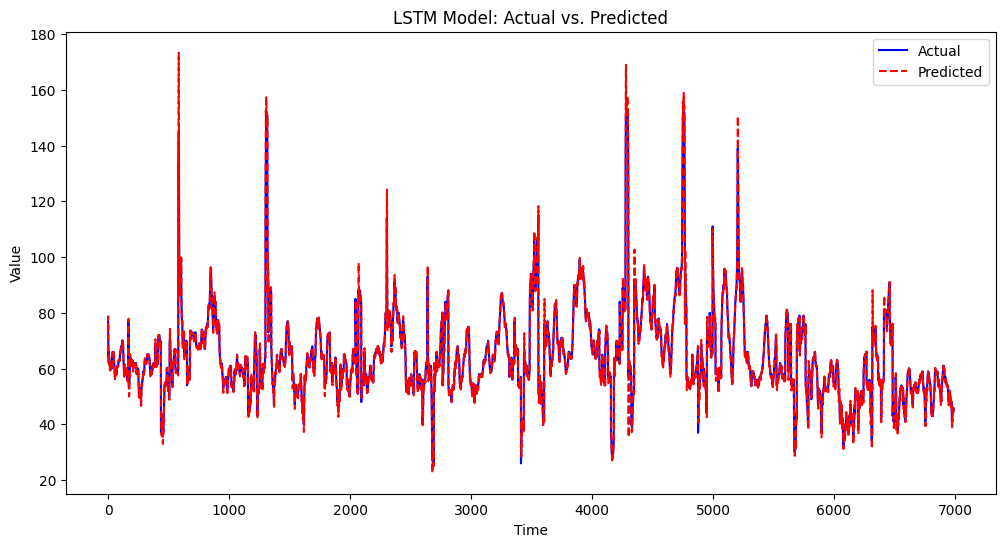

In [9]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label="Actual", linestyle="-", color="blue")
plt.plot(y_pred_inv_autoregressive, label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("LSTM Model: Actual vs. Predicted")
plt.legend()

filename_png_autoregressive = f"{filename}-autoregressive.png"
# Save the DataFrame as a CSV file in the created folder
plt.savefig(os.path.join(folder_path, filename_png_autoregressive))
plt.show()


In [10]:
# Assuming y_pred_inv and y_test_inv are already defined
df = pd.DataFrame({
    'prediction': y_pred_inv_autoregressive,
    'actual': y_test_inv,
})

filename_csv_autoregressive = f"{filename}-autoregressive.csv"
# Save the DataFrame as a CSV file in the created folder
df.to_csv(os.path.join(folder_path, filename_csv_autoregressive))


## Recursive Prediction

Make predictions:

In [11]:
# Perform Recursive LSTM for forecasting
n_steps = X_test.shape[0]  # Number of steps to forecast
input_seq = X_test[:n_steps].copy()  # This is the input sequence for the model (e.g., from the test data)

# Make predictions recursively
predictions = []

for i in range(n_steps):
  # Predict the next value
  next_pred = model.predict(input_seq[i].reshape(1, window_size, -1), verbose=0)  # Predicting the next time step

  # Append the prediction to the list
  predictions.append(next_pred[0, 0])

  if i==n_steps-1:
      break

  # Update the input sequence by adding the predicted value
  input_seq[i+1,-1,-1]=next_pred[0, 0]

In [12]:
import numpy as np

y_pred_recursive = np.array(predictions).reshape(-1, 1)
y_pred_copies_array_recursive = np.repeat(y_pred_recursive,
                                test_data_scaled.shape[1],
                                axis=-1) #change shape to use inverse_transform

# Check for NaN or Inf in any column of each row
invalid_rows_mask = np.any(
    np.isnan(y_pred_copies_array_recursive) | 
    np.isinf(y_pred_copies_array_recursive), axis=1
)

if invalid_rows_mask.any():
    print("Warning: Found invalid values (NaN or Inf) in y_pred_copies_array_recursive.")

    # Get the row indices with any invalid values
    invalid_row_indices = np.where(invalid_rows_mask)[0]

    # Convert to contiguous ranges for cleaner output
    def get_ranges(indices):
        ranges = []
        start = prev = indices[0]
        for idx in indices[1:]:
            if idx == prev + 1:
                prev = idx
            else:
                ranges.append((start, prev))
                start = prev = idx
        ranges.append((start, prev))  # add last range
        return ranges

    row_ranges = get_ranges(invalid_row_indices)

    for start, end in row_ranges:
        if start == end:
            print(f"→ Invalid value in row {start}")
        else:
            print(f"→ Invalid values in rows {start} to {end}")

    # Replace NaN and Inf with 0
    y_pred_copies_array_recursive = np.nan_to_num(
        y_pred_copies_array_recursive,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


In [13]:
y_pred_inv_recursive = scaler.inverse_transform(y_pred_copies_array_recursive)[:,-1]

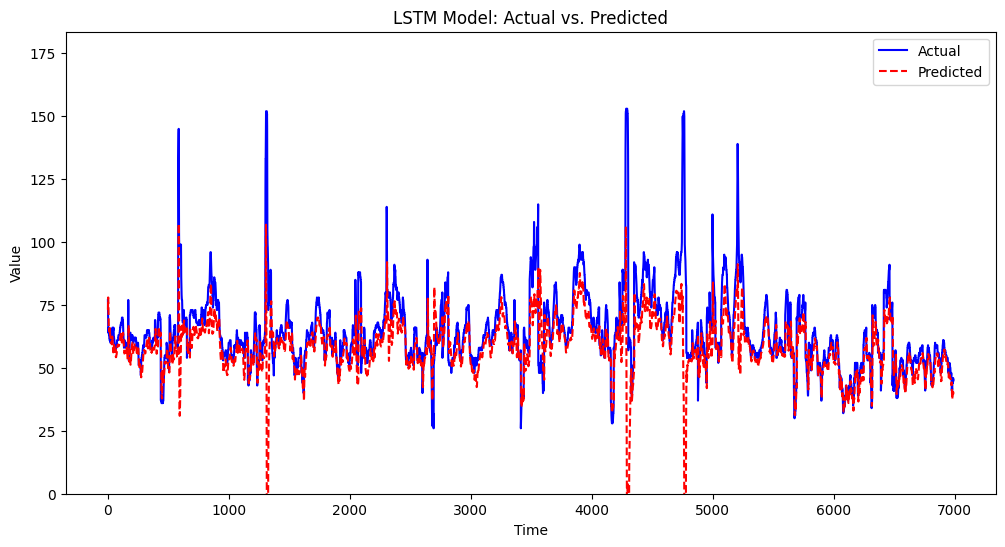

In [14]:
import matplotlib.pyplot as plt

# Create a mask for valid predictions
valid_pred_mask = ~invalid_rows_mask

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label="Actual", linestyle="-", color="blue")
plt.plot(y_pred_inv_recursive[valid_pred_mask], label="Predicted", linestyle="dashed", color="red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("LSTM Model: Actual vs. Predicted")
plt.legend()

# Set y-axis limits
plt.ylim(bottom=0, top=np.max(y_test_inv) * 1.2)

filename_png_recursive = f"{filename}-recursive.png"

# Save the DataFrame as a CSV file in the created folder
plt.savefig(os.path.join(folder_path, filename_png_recursive))
plt.show()


In [15]:
# Assuming y_pred_inv and y_test_inv are already defined
df = pd.DataFrame({
    'prediction': y_pred_inv_recursive,
    'actual': y_test_inv,
})

filename_csv_recursive = f"{filename}-recursive.csv"
# Save the DataFrame as a CSV file in the created folder
df.to_csv(os.path.join(folder_path, filename_csv_recursive))


## Evaluation

In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

def evaluate_results(results):
    
    # Find rows where the value is inf or -inf
    inf_mask = results['prediction'].isin([np.inf, -np.inf])

    # Get the first index where it's True (i.e., the first inf)
    invalid_start = results[inf_mask].index.min()
    
    if pd.isna(invalid_start):
        invalid_start = None
    
    results = results[:invalid_start]
    # Assuming you have a DataFrame called df with columns 'prediction' and 'actual'
    y_true = results['actual'].values
    y_pred = results['prediction'].values

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"RMSE: {rmse:.4f}")

    # MAE
    mae = mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae:.4f}")

In [2]:
autoregressive_results = pd.read_csv('../models/lstm/CA20B/window-24-hour/2025-04-07_16-25-13/CA20B-24-hour-autoregressive.csv')
print("Autoregressive Test Results:")
evaluate_results(autoregressive_results)

Autoregressive Test Results:
RMSE: 3.1766
MAE: 1.2013


In [3]:
recursive_results = pd.read_csv('../models/lstm/CA20B/window-24-hour/2025-04-07_16-25-13/CA20B-24-hour-recursive.csv')
print("Recursive Test Results:")
evaluate_results(recursive_results)

Recursive Test Results:
RMSE: 17.8982
MAE: 7.7753
